In [84]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

In [85]:
# sklearn imports
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)

In [86]:
# read csv
df = pd.read_csv("large_tot_df.csv")

In [87]:
df.head(5)

,Unnamed: 0,sentence,record_type,keyword,loss,wctc_loss,pred_strings
0,0,kúkù ŋgá kɛ̀cí ɛ́ɾáðɛ́ nɛ̀ rî,negative,àpɾí,633.209473,40.025875,bb<blk>bɒbbʷʷbbb<blk>ʷ<blk>ɒbʷɒɒɒʷʷʷ<blk>bbɹ<b...
1,1,láɾl̀à ðə́ɟíðɔ́ dìjɔ́ nd̪ɔ̀bà,negative,àpɾí,601.036743,39.749714,bbbbbbbbbbbbbbbbbɔbbbbbbb<blk>b<blk>b<blk>bbɒb...
2,2,ðɔ̀mɔ̀cɔ̀ ðápàt̪ɛ̀ àpɾíɲá ɛ̀ðɛ̀,close_negative,àpɾí,589.775330,39.951847,bbb<blk>bbbbbʎbbbʎʎʷbɒʎʎ<blk>bbbʷbɒʷbɒbɒbbʷɒbb...
3,3,t̪átɛ́ ùnɛ́ɾɛ́ újɛ̀l,negative,àpɾí,533.147278,39.834587,b<blk>bɹb<blk>ɹ<blk>bb<blk>bbbbbʷʷɒɒɒɒɑɒɒɒʎʷʷɒ...
4,4,kńnà àpɾí jɛ́ àɾɔ́ ðówɛ́ íðɔ̀,positive,àpɾí,525.720093,40.537830,b<blk><blk>ɹbb<blk>bbbʟbbbb<blk>b<blk>bbb<blk>...


In [88]:
df.loc[1]['pred_strings']

'bbbbbbbbbbbbbbbbbɔbbbbbbb<blk>b<blk>b<blk>bbɒbbbǂɑʷʜɒʷɒɒɒʷɑǂɒɒɒʷɒǂɒɒbʷɒɒʎbbbbb<blk>bbbbbbɒɒbɒbbbbbɒbɒɒɒɒʷʷbʷbbb<blk>bbbbb<blk>bbbbbbbbbbbbbbɒɒbbb<blk>b<blk>b<blk>bbbbbbɒbʎbɒʎʎb<blk>ʷʎʎbbbbɒbbbbbɒʎbʛʷʷʎʎɒɒbbʎɒbbbbbbbbbbbb<blk>b<blk><blk><blk>bb<blk><blk>b<blk>'

In [89]:
df["keyword"].value_counts()

keyword
àpɾí           120
ðɔ̀mɔ̀cɔ̀        120
lɛ́ŋgɛ́n         120
ŋɔ̀ɽíŋgɔ́       120
mùðù           120
ùɾnɔ̀           120
ðàŋàl          120
kə̀və̀lɛ̀ðɔ́     120
kàŋú           120
íŋgá_nɔ̀nà    120
Name: count, dtype: int64

In [90]:
df["keyword"].unique()

array(['àpɾí', 'ðɔ̀mɔ̀cɔ̀', 'lɛ́ŋgɛ́n', 'ŋɔ̀ɽíŋgɔ́', 'mùðù',
       'ùɾnɔ̀', 'ðàŋàl', 'kə̀və̀lɛ̀ðɔ́', 'kàŋú', 'íŋgá_nɔ̀nà'],
      dtype=object)

In [72]:
kws = []
all_aps = []
all_aucs = []
fn_aps = []
fn_aucs = []
cn_aps = []
cn_aucs = []

for kw in df["keyword"].unique():
    
    kws.append(kw)
    print(kw)

    all_kws = df[df["keyword"] == kw]
    y_pred = all_kws["wctc_loss"]
    y_pred = stats.zscore(-y_pred)
    y_true = all_kws['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

    ap = average_precision_score(y_true, y_pred)
    
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    
    print(f"Average Precision: {ap:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    all_aps.append(ap)
    all_aucs.append(roc_auc)


    kw_pos_neg = all_kws[all_kws['record_type'] != 'close_negative']
    y_pred_2 = kw_pos_neg["wctc_loss"]
    y_pred_2 = stats.zscore(-y_pred_2)
    y_true_2 = kw_pos_neg['record_type'].map(
                    {'positive': 1,
                    'negative': 0}
                    )

    ap = average_precision_score(y_true_2, y_pred_2)
    
    fpr, tpr, _ = roc_curve(y_true_2, y_pred_2)
    roc_auc = roc_auc_score(y_true_2, y_pred_2)
    
    precision, recall, _ = precision_recall_curve(y_true_2, y_pred_2)
    
    print(f"Average Precision Pos Neg: {ap:.4f}")
    print(f"ROC AUC Pos Neg: {roc_auc:.4f}")

    fn_aps.append(ap)
    fn_aucs.append(roc_auc)


    kw_pos_neg = all_kws[all_kws['record_type'] != 'negative']
    y_pred_3 = kw_pos_neg["wctc_loss"]
    y_pred_3 = stats.zscore(-y_pred_3)
    y_true_3 = kw_pos_neg['record_type'].map(
                    {'positive': 1,
                    'close_negative': 0}
                    )

    ap = average_precision_score(y_true_3, y_pred_3)
    
    fpr, tpr, _ = roc_curve(y_true_3, y_pred_3)
    roc_auc = roc_auc_score(y_true_3, y_pred_3)
    
    precision, recall, _ = precision_recall_curve(y_true_3, y_pred_3)
    
    print(f"Average Precision Close Neg: {ap:.4f}")
    print(f"ROC AUC Close Neg: {roc_auc:.4f}")

    cn_aps.append(ap)
    cn_aucs.append(roc_auc)

'''
print(f"{len(kws)=}")
print(f"{len(all_aps)=}")
print(f"{len(all_aucs)=}")
print(f"{len(fn_aps)=}")
print(f"{len(fn_aucs)=}")
print(f"{len(cn_aps)=}")
print(f"{len(cn_aucs)=}")
'''

df_2 = pd.DataFrame({"keyword":kws, "all_aps":all_aps, "all_aucs": all_aucs, "far_neg_only_aps":fn_aps, "far_neg_only_aucs":fn_aucs, "close_neg_only_aps":cn_aps, "close_neg_only_aucs":cn_aucs})
df_2

df_2.to_csv('analysis_dfs/aucs.csv')

àpɾí
Average Precision: 0.0774
ROC AUC: 0.4300
Average Precision Pos Neg: 0.0816
ROC AUC Pos Neg: 0.4080
Average Precision Close Neg: 0.6223
ROC AUC Close Neg: 0.6500
ðɔ̀mɔ̀cɔ̀
Average Precision: 0.1043
ROC AUC: 0.6000
Average Precision Pos Neg: 0.1131
ROC AUC Pos Neg: 0.6000
Average Precision Close Neg: 0.5548
ROC AUC Close Neg: 0.6000
lɛ́ŋgɛ́n
Average Precision: 0.2119
ROC AUC: 0.6173
Average Precision Pos Neg: 0.2192
ROC AUC Pos Neg: 0.6260
Average Precision Close Neg: 0.6948
ROC AUC Close Neg: 0.5300
ŋɔ̀ɽíŋgɔ́
Average Precision: 0.1020
ROC AUC: 0.5155
Average Precision Pos Neg: 0.1134
ROC AUC Pos Neg: 0.5170
Average Precision Close Neg: 0.5189
ROC AUC Close Neg: 0.5000
mùðù
Average Precision: 0.1779
ROC AUC: 0.6055
Average Precision Pos Neg: 0.1827
ROC AUC Pos Neg: 0.5930
Average Precision Close Neg: 0.7632
ROC AUC Close Neg: 0.7300
ùɾnɔ̀
Average Precision: 0.0743
ROC AUC: 0.4164
Average Precision Pos Neg: 0.0811
ROC AUC Pos Neg: 0.4160
Average Precision Close Neg: 0.4668
ROC

In [73]:
for col in df_2.columns:
    if col == "keyword":
        continue
    else:
        print(col)
        print(df_2[col].mean())
        print(df_2[col].std())

all_aps
0.12809665095543
0.043224312329964355
all_aucs
0.5472727272727272
0.08599015468876431
far_neg_only_aps
0.13711672153111476
0.04359775957032916
far_neg_only_aucs
0.546
0.09282121405033322
close_neg_only_aps
0.5965793360835929
0.0956105627629605
close_neg_only_aucs
0.56
0.09865765724632497


In [74]:
all_aps

[0.0774343231293129,
 0.10425200549619273,
 0.21186227578917305,
 0.10202366098541857,
 0.17787858759161762,
 0.07433279111988876,
 0.11864621348311274,
 0.15017747580092083,
 0.13365320860839816,
 0.13070596755026437]

In [75]:
all_aucs = list(set(all_aucs))
all_auc_avg = sum(all_aucs)/len(all_aucs)
all_auc_avg

0.5472727272727272

In [76]:
fn_aucs = list(set(fn_aucs))
fn_auc_avg = sum(fn_aucs)/len(fn_aucs)
fn_auc_avg

0.546

In [77]:
cn_aucs = list(set(cn_aucs))
cn_auc_avg = sum(cn_aucs)/len(cn_aucs)
cn_auc_avg

0.56

In [95]:
kw_df = df[df["keyword"] == kw]

y_pred = kw_df["wctc_loss"]
kw_df["y_pred"] = stats.zscore(-y_pred)

kw_df = kw_df.sort_values(by="wctc_loss", ascending=True)

#type_order = ["positive", "close_negative", "negative"]
#kw_df['record_type'] = pd.Categorical(df['record_type'], categories=type_order, ordered=True)
kw_df = kw_df.sort_values('record_type', ascending=False)

kw_df.tail(60)

/tmp/ipykernel_2415295/2716069413.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kw_df["y_pred"] = stats.zscore(-y_pred)


,Unnamed: 0,sentence,record_type,keyword,loss,wctc_loss,pred_strings,y_pred
1130,24,kɛ́ɾá nɔ́ðɛ̀,negative,íŋgá_nɔ̀nà,98.810654,76.982552,ʷʷǂʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷʷ<blk><blk><blk>ɹb<blk><...,-0.862158
1183,8,lə̀ǹɔ́ nɔ́ŋnɔ̀ ùnɛ́ɾɛ́,negative,íŋgá_nɔ̀nà,360.404755,76.339127,<blk>ʎb<blk>bʎbbbɒɒʎʷʷbʎbbbbbbbbʎbɒɒʷɒʷʷʷbbɒʎɒ...,-0.209699
1098,9,lɜ̀dí álɛ́ ùnɛ́ɾɛ́,negative,íŋgá_nɔ̀nà,266.200806,76.354042,bbɒbbʷɒɒɒɒbbɒɒʷɒbɒɒʷbɒɒɒɒɒɒʷɒɒʷɒɒǂᶑʷʷʷɒʷɒɒɒɒbɒ...,-0.224824
1185,1,t̪ɔ́ɾt̪ɔ́l lə́dɔ̀ŋðàt̪ɛ̀ lə̀vàvɾà dún t̪ɔ́...,negative,íŋgá_nɔ̀nà,506.832184,76.263588,ʎʟɒʎɒɒʷʷʎʷʷɒʎbɒɒbbɒbɒbɒwɒʷʷɒɒɒɒɒʷʷɒʎɒʷʎɒɒɒʷbʷʎ...,-0.133100
1132,0,ŋìðɛ̀ní ŋàcìjí t̪ɔ́wɜ̀nì,negative,íŋgá_nɔ̀nà,306.321838,76.322647,ʷʷɒʷʷʷɒʷbɒɒɒɒɒʷɒʷɒʷɒɒɒʷɒɒɒɒɒɒɒɒɒbbɒbʷɒʷbɒɒʷɒʎb...,-0.192989
1131,25,ḿɔ́,negative,íŋgá_nɔ̀nà,89.949371,75.152626,bb<blk>b<blk>bb<blk>ɒɒbʎʷbbɒbʎbɹbbbb<blk><blk>...,0.993459
1192,8,àn ɔ́ɟɔ́ kə́ðìɲɔ́ múðù,negative,íŋgá_nɔ̀nà,429.765594,76.264221,bbbbbbʟbɒʎʷɒǂʷʷɒǂʷɒʷɒɑǂǂɒɒɒɒɒɒɒɒʷʷɒɒʷɒʷʷɒʷʷɒʷɒ...,-0.133742
1165,4,kə̀ŋàcáŋá,negative,íŋgá_nɔ̀nà,342.067017,75.487633,bbbbbbbbɒbɒbbbɒbbɒbbbbbʟʷbɒʟɒɒʷɑʎɒɒɒʷɒɒʎɑʷɒɒɒɒ...,0.653749
1174,13,ɛ́là ðínd̪ɔ̀t̪ɔ̀ ɛ̀là nd̪ɔ̀bà,negative,íŋgá_nɔ̀nà,326.548187,75.441895,bbb<blk>bbbbbʷʷʎɒɒɒbɒǂɒʷɒbɒʷɒɒʎʎbbɒbʎɒb<blk>ʎʎ...,0.700130
1123,17,áɾðɔ́ t̪ɔ́wɜ̀nì,negative,íŋgá_nɔ̀nà,157.956650,75.399551,bbbɒɒɒɒɒɒɒɒɒʷɒɒɒzʎʷɒɒɒɒɒʷbʎɒbʎɒɒbʷbʎʷɒɒbbbbbb<...,0.743067


In [96]:
# make dataframes for each keyword to analyze the dataframe slices respectively
parent_dir = "analysis_dfs"

for kw in kws:

    kw_df = df[df["keyword"] == kw]

    kw_df = kw_df.sort_values(by="wctc_loss", ascending=True, kind='stable')
    kw_df.to_csv(f'{parent_dir}/{kw}.csv')

## Keyword: "àpɾí"

In [68]:
kws.append("àpɾí")

In [69]:
# select keyword for dataframe
ap_kw_df = df[df["keyword"] == "àpɾí"]
ap_kw_df.shape

(120, 7)

In [70]:
# make z scored prediction column
y_pred = ap_kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [71]:
# map true values to respective binary values
y_true = ap_kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [72]:
y_true

0      0
1      0
2      0
3      0
4      1
      ..
115    1
116    0
117    1
118    0
119    1
Name: record_type, Length: 120, dtype: int64

In [73]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

all_aucs.append(ap)
all_rocs.append(roc_auc)

Average Precision: 0.0774
ROC AUC: 0.4300


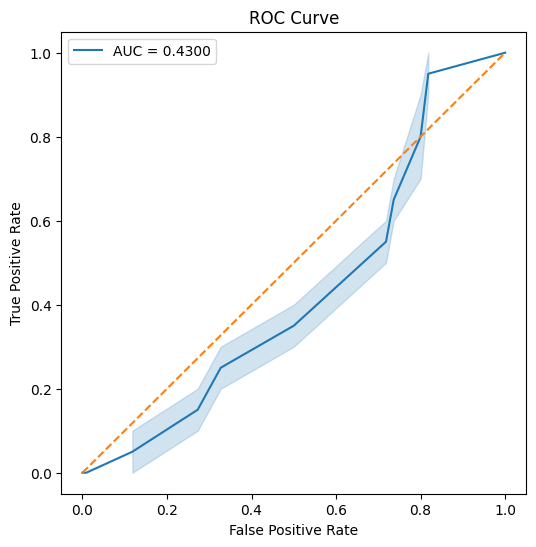

In [12]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

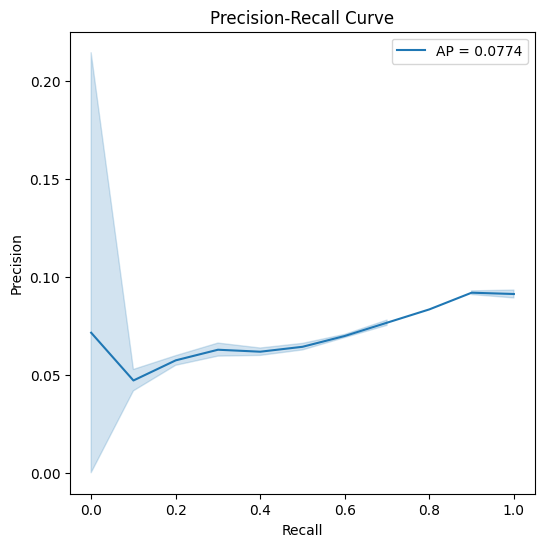

In [13]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [14]:
# let's try looking at only the positives and negatives
# to do this, first we can filter the dataframe to get only these values
ap_kw_pos_neg = ap_kw_df[ap_kw_df['record_type'] != 'close_negative']
ap_kw_pos_neg.shape

(110, 7)

In [15]:
ap_kw_pos_neg

,Unnamed: 0,sentence,record_type,keyword,loss,wctc_loss,pred_strings
0,0,kúkù ŋgá kɛ̀cí ɛ́ɾáðɛ́ nɛ̀ rî,negative,àpɾí,633.209473,40.025875,bb<blk>bɒbbʷʷbbb<blk>ʷ<blk>ɒbʷɒɒɒʷʷʷ<blk>bbɹ<b...
1,1,láɾl̀à ðə́ɟíðɔ́ dìjɔ́ nd̪ɔ̀bà,negative,àpɾí,601.036743,39.749714,bbbbbbbbbbbbbbbbbɔbbbbbbb<blk>b<blk>b<blk>bbɒb...
3,3,t̪átɛ́ ùnɛ́ɾɛ́ újɛ̀l,negative,àpɾí,533.147278,39.834587,b<blk>bɹb<blk>ɹ<blk>bb<blk>bbbbbʷʷɒɒɒɒɑɒɒɒʎʷʷɒ...
4,4,kńnà àpɾí jɛ́ àɾɔ́ ðówɛ́ íðɔ̀,positive,àpɾí,525.720093,40.537830,b<blk><blk>ɹbb<blk>bbbʟbbbb<blk>b<blk>bbb<blk>...
5,5,àn ɔ́ɟɔ́ kə́ŋàcí kúkù ðɔ̀ndà,negative,àpɾí,380.515228,39.910473,bbbbbbbbbbbbbbʎbb<blk>bbbbʎbbbbb<blk>bbbbbbbʷb...
...,...,...,...,...,...,...,...
113,0,jít̪ɔ́ ílí lɔ́ɽá ŋìðìjí kə̀r̀nà kàɾó...,negative,àpɾí,1081.815430,38.779808,ǂɒɒɒɒʷɒʷɒbɒɒʷɒɒɒʷǂɒɒɒǂɒɒʷʎɒɒɒɒɒɒɒɒɒʷɒɒɒɒⱱɒʷɒɒʜ...
114,1,àn èdɛ̀ɽì kɛ̀ɾɔ́ íŋgá ŕnà ŋrɔ̂bà,negative,àpɾí,765.992615,38.788506,bbɒbɒʎɒɒɒɒɒɒɒɒɒǂbɒbbʎbʎbbb<blk>bɒb<blk>bbɒɒɒɒɒ...
115,2,àpɾí lɛ́ŋgɛ́n ŋídɔ̀t̪ɔ́ lídí nə̀ǹɔ́ jɛ́a...,positive,àpɾí,816.600586,39.323124,bʟbʟbɹ<blk>bb<blk>bbbbbbʎʟʎgʟʎʜʜbʎbbbʷbbǂiǂǂbǂ...
117,4,àpɾí jámìɲí lɛ́ŋgɛ́n jámìɲí ðíɲɔ̀,positive,àpɾí,661.915649,40.687626,ʷʷǂbbʎʷbbʎbbʷbʷbɒɒɒɑɒɒɒɒʷɒɒɒbǂbʎbbbbbbbbbbb<bl...


In [16]:
# having dropped exactly 10 rows, now we can expect y_true to be 110
y_true = ap_kw_pos_neg['record_type'].map(
                    {'positive': 1,
                    'negative': 0}
                    ).reset_index(drop=True)
y_true

0      0
1      0
2      0
3      1
4      0
      ..
105    0
106    0
107    1
108    1
109    1
Name: record_type, Length: 110, dtype: int64

In [17]:
# y pred needs to be applied to this subset dataframe
# make z scored prediction column
y_pred = ap_kw_pos_neg["wctc_loss"]
y_pred = stats.zscore(-y_pred)
len(y_pred)
y_pred

array([ 0.20845263,  0.55665965,  0.44964445, -0.43706319,  0.35396135,
       -0.91967772,  0.74025307,  2.35796747,  0.82438763,  2.01879342,
       -0.25174783,  0.40354168,  0.14508235, -1.18242746,  1.04136167,
       -0.1828077 ,  0.93781441, -2.60250838, -2.16906052, -1.1520434 ,
       -2.04031426,  0.11427983, -0.1272054 , -0.10741752, -0.45607667,
       -0.67512859,  1.19226228,  0.84926437, -0.26307511, -2.41011768,
        0.01226211,  1.09412133, -0.43899195, -0.30088083,  1.45024543,
        0.66298703, -0.86733171,  1.20011202, -0.2916699 , -2.70309757,
       -1.48946185, -0.30870652, -1.72354466, -0.61626037, -1.74176451,
       -0.99473121, -0.59105656, -1.17493847,  0.21129046, -3.33721395,
        0.79603815,  0.62184806, -0.15038906, -1.76983983,  1.19201217,
       -0.04241189, -0.04353259,  0.27867699, -0.02516844,  0.01759147,
        0.13130683,  1.19691826,  0.76650544,  0.0739874 , -0.23157035,
        1.09621844,  1.22504648,  0.20234888, -0.25991502,  0.27

In [18]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.0816
ROC AUC: 0.4080


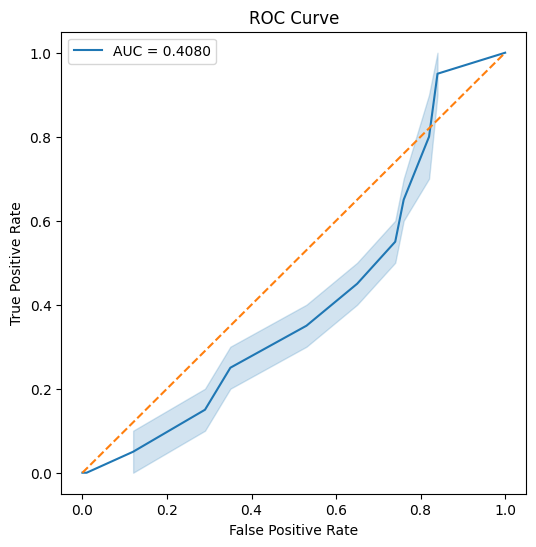

In [19]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

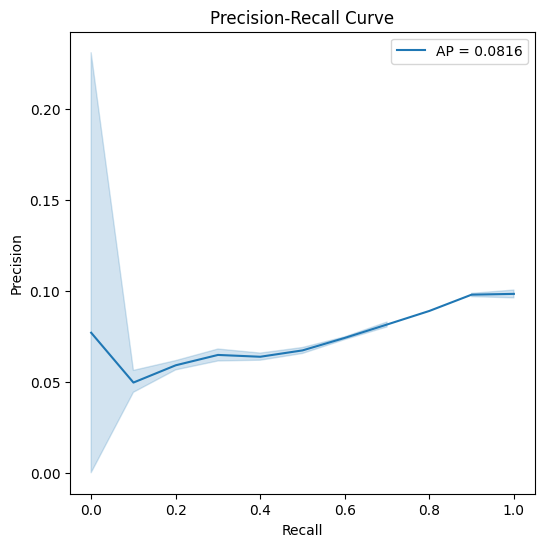

In [20]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [22]:
# let's try looking at only the positives and negatives
# to do this, first we can filter the dataframe to get only these values
ap_kw_pos_close = ap_kw_df[ap_kw_df['record_type'] != 'negative']
ap_kw_pos_close.shape

(20, 7)

In [25]:
# having dropped exactly 10 rows, now we can expect y_true to be 110
y_true = ap_kw_pos_close['record_type'].map(
                    {'positive': 1,
                    'close_negative': 0}
                    ).reset_index(drop=True)
y_true

0     0
1     1
2     1
3     0
4     0
5     0
6     0
7     1
8     0
9     1
10    1
11    1
12    0
13    1
14    0
15    1
16    0
17    1
18    0
19    1
Name: record_type, dtype: int64

In [27]:
# y pred needs to be applied to this subset dataframe
# make z scored prediction column
y_pred = ap_kw_pos_close["wctc_loss"]
y_pred = stats.zscore(-y_pred)
len(y_pred)
y_pred

array([ 0.70608343, -0.05748538, -0.55624177, -0.64688363, -0.17239947,
        0.17997293, -1.31116642,  0.76853112,  1.96895541,  0.48390027,
        0.23174839,  0.96550753, -2.61511678,  0.09166733,  0.16953433,
        1.52534466,  0.17828287, -0.25267729, -1.38979394, -0.26776356])

In [28]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.6223
ROC AUC: 0.6500


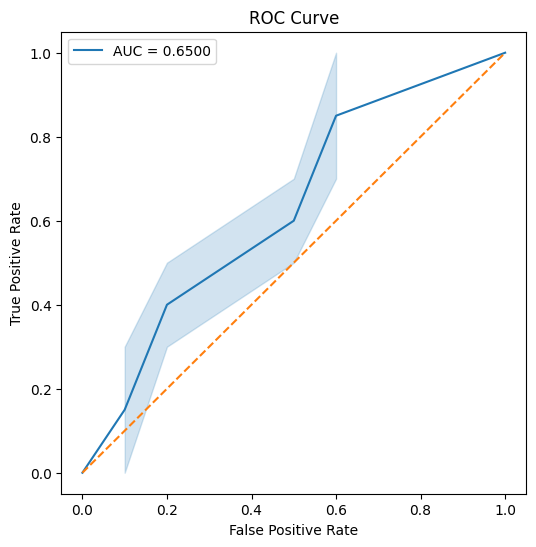

In [29]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

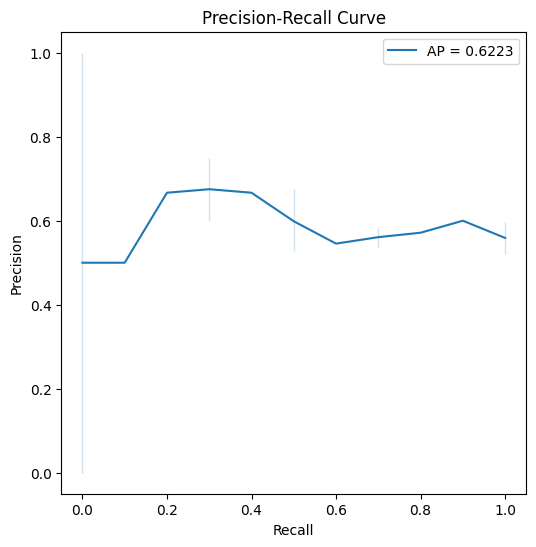

In [31]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [35]:
ap_kw_pos_close.sort_values(by="wctc_loss", ascending=False)

,Unnamed: 0,sentence,record_type,keyword,loss,wctc_loss,pred_strings
108,4,kúkù kà káɾìjì àpɾíɲá ðówɛ́,close_negative,àpɾí,339.372864,42.500626,<blk>tɹ<blk><blk><blk><blk><blk><blk><blk>ɨ<bl...
118,5,ðɔ̀mɔ̀cɔ̀ ðápàt̪ɛ̀ àpɾíɲá ɛ̀ðɛ̀ ùnɛ́ɾɛ́,close_negative,àpɾí,558.991760,41.560280,<blk>ǂʷɪʷʷ<blk>ɪʷʷʷʷ<blk>ʷɪʷʷɨʷʷɨɪ<blk>ʷɪɪǂʷʷʷ...
86,5,kúkù ká útìðìjɔ̀ àpɾíɲá lɛ́ŋgɛ́n,close_negative,àpɾí,239.807861,41.499939,<blk>b<blk><blk>b<blk>bbb<blk>bbbb<blk><blk><b...
7,7,ðàŋàl ðá və́lɛ̀ðà àpɾíɲá nd̪ɔ̀bà,close_negative,àpɾí,450.131195,40.990150,ɨɪɪǂ<blk><blk>tɪ<blk>ɪʷ<blk>ʷʷ<blk>ʷʷɪʷʷʷʷʷʷʷʷ...
6,6,àpɾí jáŋcìnɛ̀ kúkùŋú,positive,àpɾí,366.684845,40.920589,bb<blk>bbbb<blk>bbbbbb<blk>bb<blk>bbbbbbʷʷbʷʷb...
119,6,àpɾí jáɾɔ́jɛ́ ùrnɔ̀ t̪á jə̀mɛ̀ɾðɔ́ t̪ùdi...,positive,àpɾí,477.622467,40.699203,bb<blk><blk>b<blk>b<blk>bb<blk>bb<blk>bbb<blk>...
117,4,àpɾí jámìɲí lɛ́ŋgɛ́n jámìɲí ðíɲɔ̀,positive,àpɾí,661.915649,40.687626,ʷʷǂbbʎʷbbʎbbʷbʷbɒɒɒɑɒɒɒɒʷɒɒɒbǂbʎbbbbbbbbbbb<bl...
66,14,kúkù kájì àpɾíɲá ŋɔ̀mɔ̀,close_negative,àpɾí,188.644073,40.626019,b<blk><blk><blk><blk>b<blk>b<blk>bb<blk><blk>b...
4,4,kńnà àpɾí jɛ́ àɾɔ́ ðówɛ́ íðɔ̀,positive,àpɾí,525.720093,40.537830,b<blk><blk>ɹbb<blk>bbbʟbbbb<blk>b<blk>bbb<blk>...
109,5,àpɾí jáŋɛ̂ və̀lɛ̀ðɔ́ nd̪ɔ̀bàgɛ̀,positive,àpɾí,459.337036,40.423367,bbbbbbbʟbbbbʷʷbʷʷbʷbbbbbʷʷʷɒʷɒʷɒʷɒɒʷʎɑʷʷbb<blk...


In [48]:
y_pred = ap_kw_pos_neg["wctc_loss"]
y_pred = -((ap_kw_pos_neg['wctc_loss'] - ap_kw_pos_neg['wctc_loss'].mean()) / ap_kw_pos_neg['wctc_loss'].std())
y_pred

0      0.207503
1      0.554124
3      0.447596
4     -0.435072
5      0.352349
         ...   
113    1.771490
114    1.760574
115    1.089553
117   -0.623086
119   -0.637618
Name: wctc_loss, Length: 110, dtype: float64

In [51]:
y_pred = -ap_kw_pos_neg["wctc_loss"]
y_pred

0     -40.025875
1     -39.749714
3     -39.834587
4     -40.537830
5     -39.910473
         ...    
113   -38.779808
114   -38.788506
115   -39.323124
117   -40.687626
119   -40.699203
Name: wctc_loss, Length: 110, dtype: float64

In [56]:
y_true

0      0
1      0
2      0
3      1
4      0
      ..
105    0
106    0
107    1
108    1
109    1
Name: record_type, Length: 110, dtype: int64

In [65]:
y_pred = ap_kw_pos_neg["loss"]
y_pred = stats.zscore(-y_pred)
y_pred

array([-2.03780058e+00, -1.83194695e+00, -1.39756376e+00, -1.35004174e+00,
       -4.20964568e-01, -3.32472399e-01,  3.03005662e-01,  2.38735908e-01,
        4.28621002e-01,  3.51341146e-01,  3.24790996e-01,  2.68479395e-01,
        5.57421868e-01,  8.99482898e-01,  3.23608091e-01,  4.47097111e-01,
        3.54929305e-01,  9.35500977e-01,  6.95108875e-01,  6.83919896e-01,
        8.84543985e-01,  6.43443468e-01,  6.29573035e-01,  3.99305240e-01,
        6.62198901e-01,  7.55796425e-01,  7.17870526e-01,  6.93232200e-01,
        8.77358782e-01,  8.87138448e-01,  8.11589700e-01,  8.37222307e-01,
        8.29520341e-01,  8.52999682e-01,  7.37396957e-01,  9.75813677e-01,
        1.10102687e+00,  8.23757827e-01,  1.17432873e+00,  1.15794838e+00,
        1.09220624e+00,  1.07459456e+00,  1.14421317e+00,  1.22950677e+00,
        1.28126176e+00,  1.33369172e+00,  1.38197653e+00,  1.54771004e+00,
        1.40719118e+00,  1.56636521e+00, -2.19251691e-01,  3.21642943e-02,
        5.94794861e-02,  

In [66]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.0551
ROC AUC: 0.1010


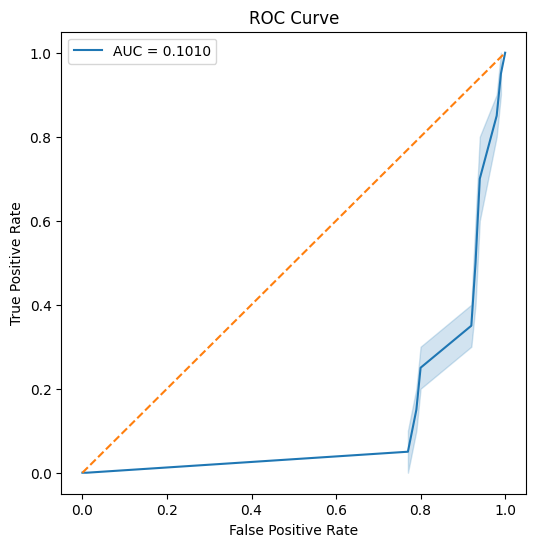

In [67]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

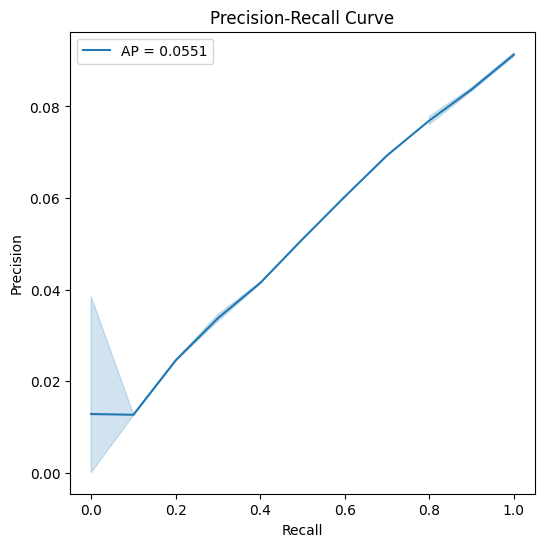

In [68]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ðɔ̀mɔ̀cɔ̀"

In [69]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ðɔ̀mɔ̀cɔ̀"]
kw_df.shape

(120, 7)

In [95]:
# make z scored prediction column
# y_pred = kw_df["wctc_loss"]
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [96]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [97]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1043
ROC AUC: 0.6000


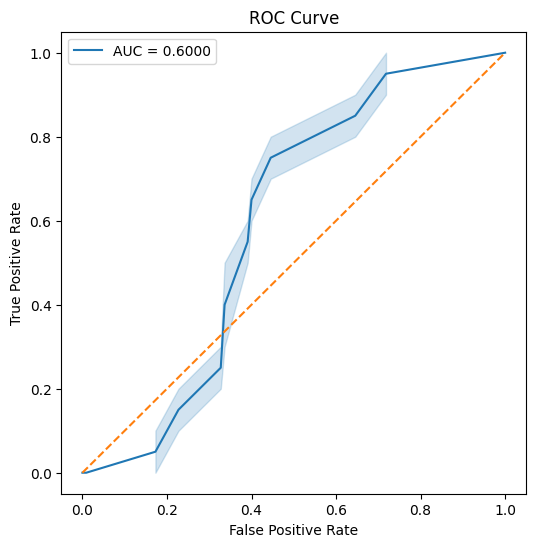

In [98]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

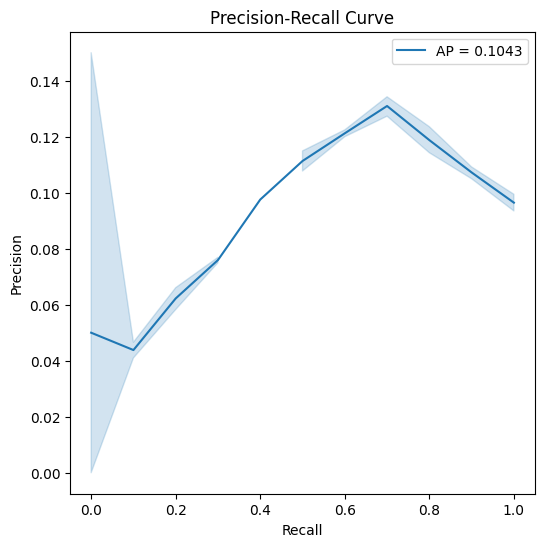

In [99]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "lɛ́ŋgɛ́n"

In [20]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "lɛ́ŋgɛ́n"]
kw_df.shape

(120, 7)

In [21]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [22]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [23]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.2119
ROC AUC: 0.6173


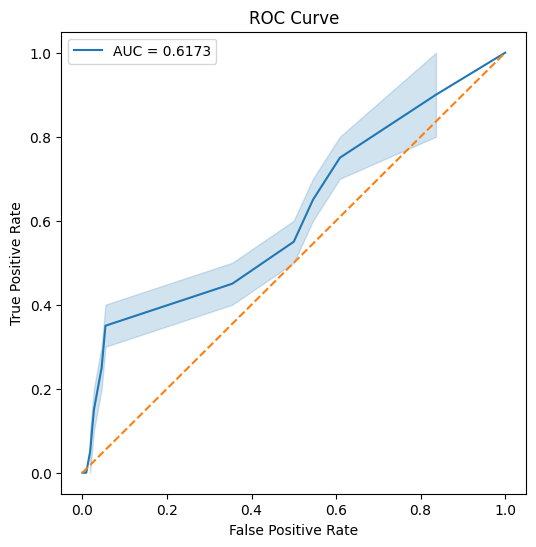

In [24]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

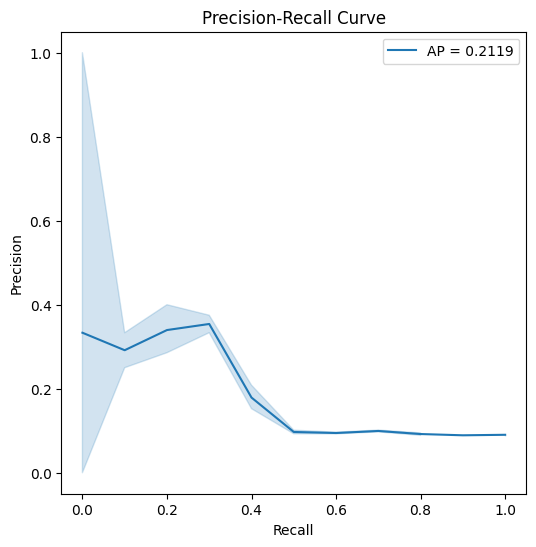

In [25]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ŋɔ̀ɽíŋgɔ́"

In [26]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ŋɔ̀ɽíŋgɔ́"]
kw_df.shape

(120, 7)

In [27]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [28]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [29]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1020
ROC AUC: 0.5155


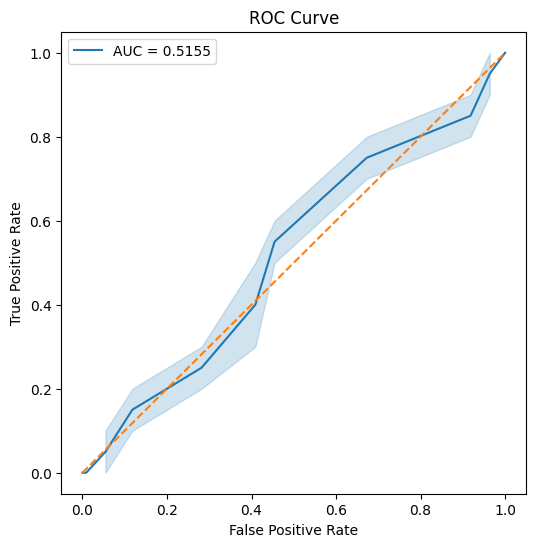

In [30]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

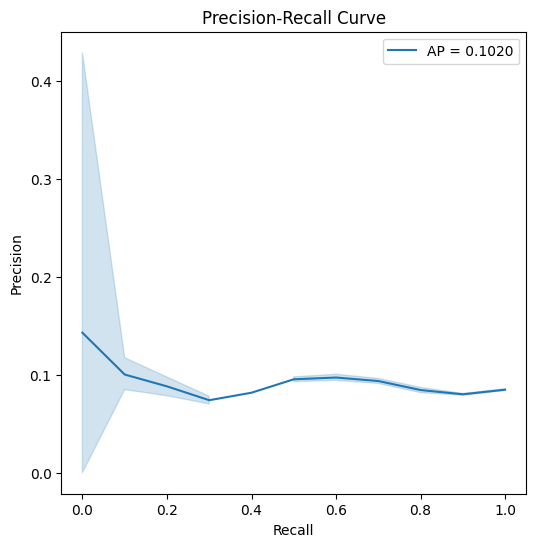

In [31]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "mùðù"

In [32]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "mùðù"]
kw_df.shape

(120, 7)

In [33]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [34]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [35]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1779
ROC AUC: 0.6055


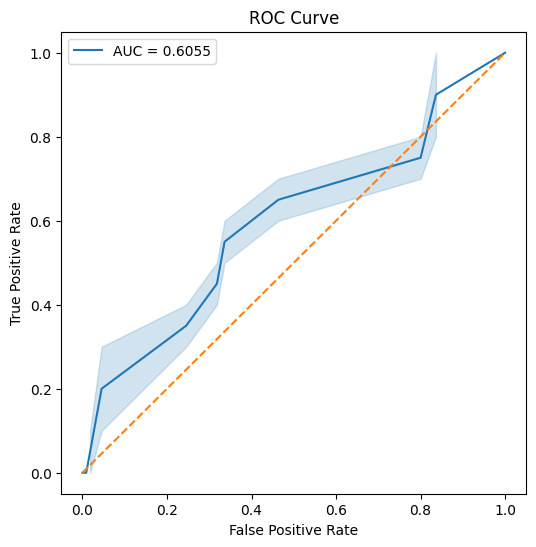

In [36]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

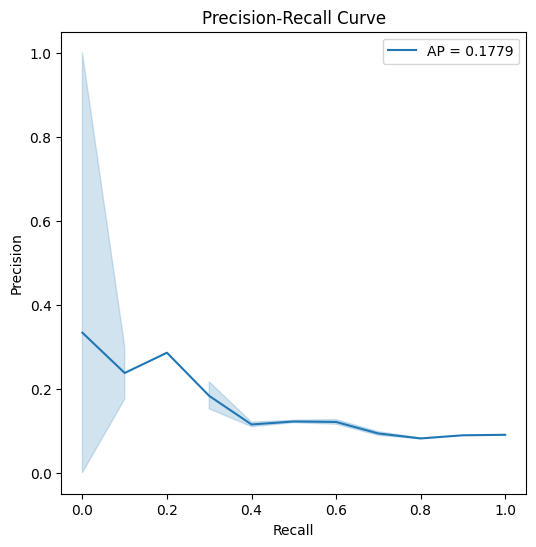

In [37]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ùɾnɔ̀"

In [38]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ùɾnɔ̀"]
kw_df.shape

(120, 7)

In [39]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [40]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [41]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.0743
ROC AUC: 0.4164


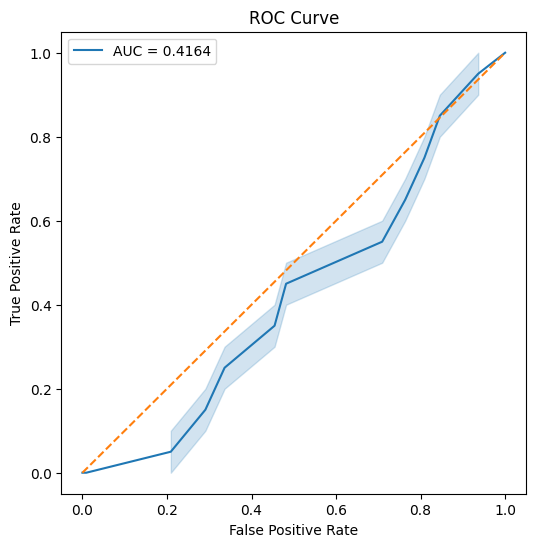

In [42]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

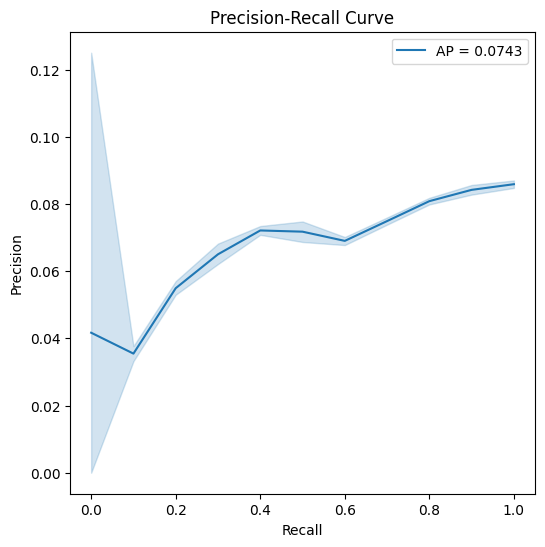

In [43]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "ðàŋàl"

In [44]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "ðàŋàl"]
kw_df.shape

(120, 7)

In [45]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [46]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [47]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1186
ROC AUC: 0.6236


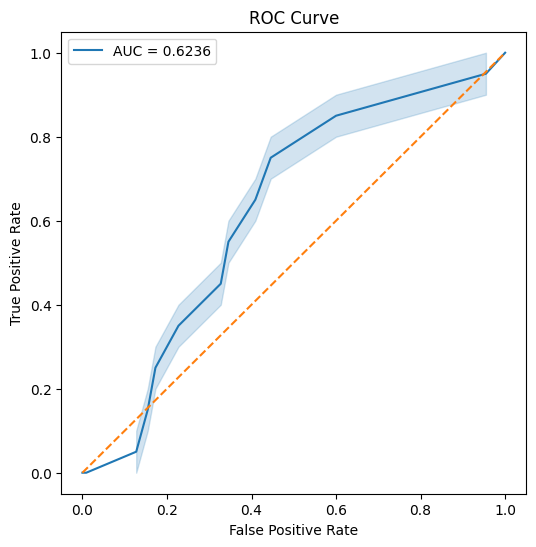

In [48]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

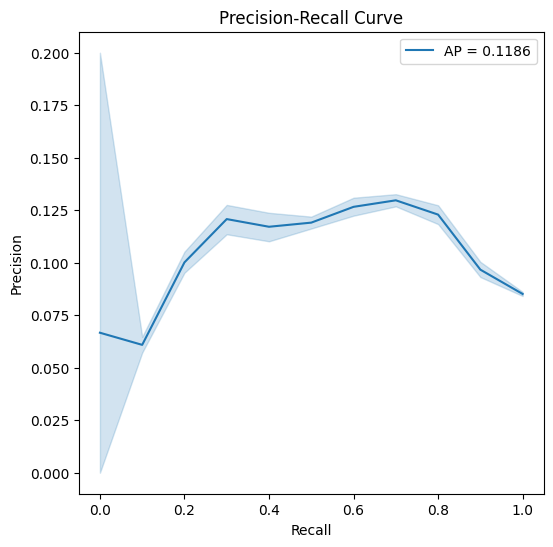

In [49]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "kə̀və̀lɛ̀ðɔ́"

In [50]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "kə̀və̀lɛ̀ðɔ́"]
kw_df.shape

(120, 7)

In [51]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [52]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [53]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1502
ROC AUC: 0.5245


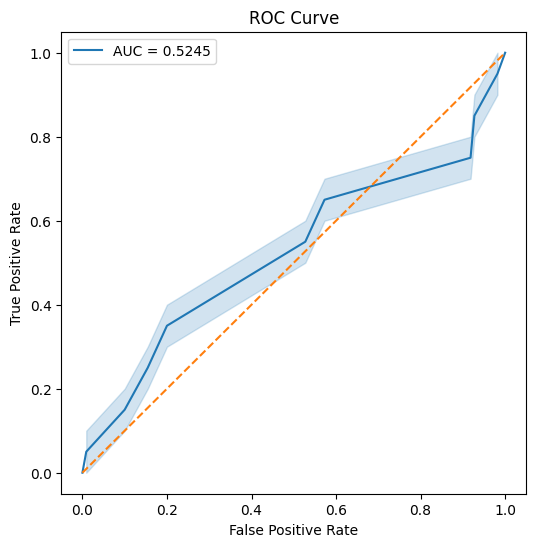

In [54]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

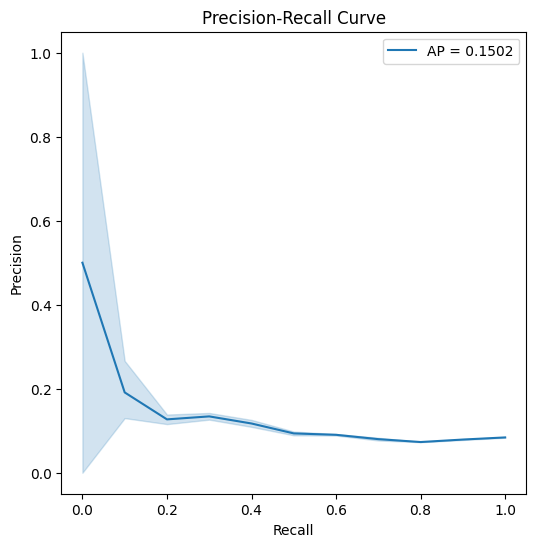

In [55]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "kàŋú"

In [56]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "kàŋú"]
kw_df.shape

(120, 7)

In [57]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [58]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [59]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1337
ROC AUC: 0.4800


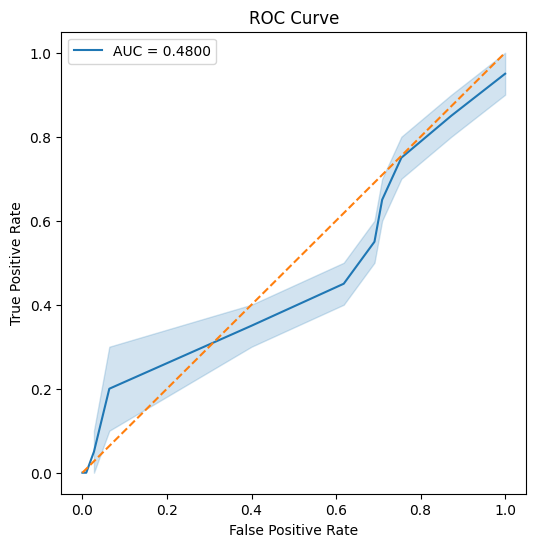

In [60]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

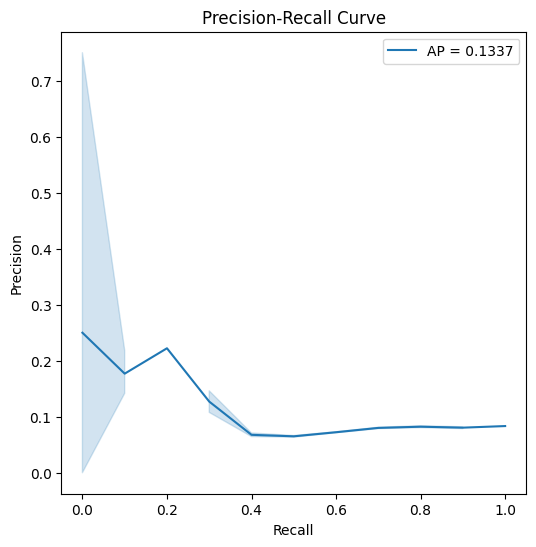

In [61]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Keyword: "íŋgá_nɔ̀nà"

In [62]:
# select keyword for dataframe
kw_df = df[df["keyword"] == "íŋgá_nɔ̀nà"]
kw_df.shape

(120, 7)

In [63]:
# make z scored prediction column
y_pred = kw_df["wctc_loss"]
y_pred = stats.zscore(-y_pred)

In [64]:
# map true values to respective binary values
y_true = kw_df['record_type'].map(
                    {'positive': 1,
                    'negative': 0,
                    'close_negative': 0}
                    )

In [65]:
# get MAP, ROC Curve, Precision-Recall Curve
ap = average_precision_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1307
ROC AUC: 0.6600


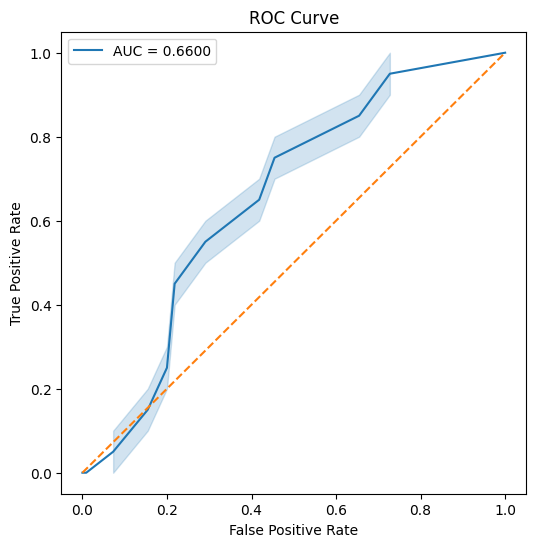

In [66]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

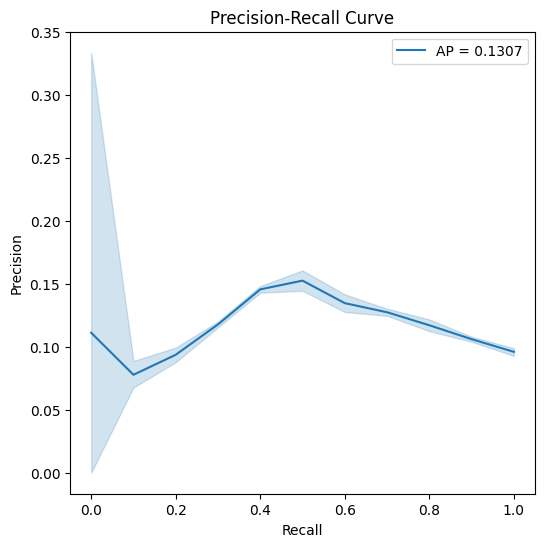

In [67]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Trying Normalized Losses with Min-Max Scaling

In [73]:
from sklearn.preprocessing import MinMaxScaler

In [74]:
#apri
losses = ap_kw_df["wctc_loss"].values.reshape(-1, 1)

scaler = MinMaxScaler()

normalized_losses = scaler.fit_transform(losses).flatten()

scores = 1 - normalized_losses

In [75]:
ap = average_precision_score(y_true, scores)

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = roc_auc_score(y_true, scores)

precision, recall, _ = precision_recall_curve(y_true, scores)

print(f"Average Precision: {ap:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Average Precision: 0.1952
ROC AUC: 0.5455


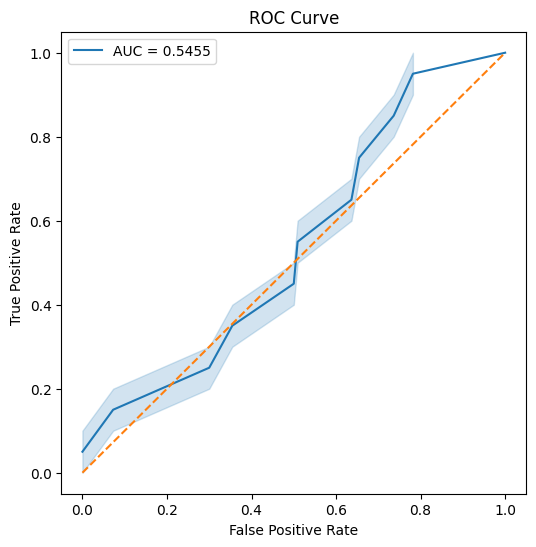

In [76]:
# ROC Curve
plt.figure(figsize=(6, 6))

sns.lineplot(x=fpr, y=tpr, label=f"AUC = {roc_auc:.4f}")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

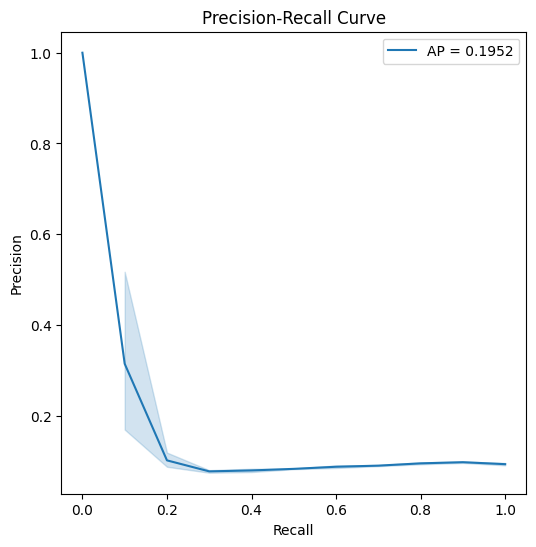

In [77]:
# Precision Recall Curve
plt.figure(figsize=(6, 6))

sns.lineplot(
    x=recall,
    y=precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()